# Fama-French 3-Factor Model — Indian Equities

**Data Sources**:
- **Individual stock prices, market cap, book value, shares**: CMIE Prowess CSV
- **Market return (NIFTY 500 index)**: Yahoo Finance (single ticker, no rate-limit concern)
- **Risk-free rate (91-day T-bill)**: FRED — IMF series `INTGSTINM193N` (pulled online)

---

## ⚠️ Known Limitations

1. **Survivorship bias**: CMIE CSV contains ~320 stocks with continuous trading data 2015–2025. Stocks that were delisted or had insufficient trading are excluded, upward-biasing returns.
2. **Book value timing**: CMIE `equity_bv_on_stkdate` reflects the most recently filed annual report. For Indian companies (March FY-end), the annual report is typically available by August. By December, BV is clean and look-ahead free.
3. **No backfill needed**: Unlike yfinance (4-year depth), CMIE provides full history from 2015. This is the primary motivation for switching data sources.
4. **3×3 test portfolios**: 320 stocks → 25 portfolios = ~13 stocks/cell, too thin. We use 3×3 = 9 portfolios.
5. **Market cap in ₹ Crore**: All CMIE monetary values are in ₹ Crore. B/M ratios are unitless (ratio of same unit), so this has no effect on sorting.

---

## Step 0: Install & Import

In [1]:
import subprocess, sys
# yfinance kept only for the NIFTY 500 index (market return — single ticker)
pkgs = ['yfinance', 'pandas', 'numpy', 'statsmodels', 'matplotlib',
        'seaborn', 'requests', 'tqdm', 'pandas_datareader', 'openpyxl']
for p in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
print('All packages installed.')

All packages installed.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import requests
import pandas_datareader.data as web
from tqdm import tqdm
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8-whitegrid')

print('Imports successful.')

Imports successful.


In [10]:
cmie_raw = pd.read_csv('/content/filtered_full_coverage_data.csv')
cmie_raw

,co_code,company_name,co_stkdate,bse_opening_price,bse_high_price,bse_low_price,bse_closing_price,bse_flags,bse_returns,bse_traded_qty,...,nse_pe,nse_pb,nse_bv_per_share,equity_shares_on_stkdate,equity_facevalue_on_stkdate,eps_on_stkdate,cons_eps_on_stkdate,ceps_on_stkdate,cons_ceps_on_stkdate,equity_bv_on_stkdate
0,36277,3M INDIA LTD.,2015-01-01,6400.2000,6538.9500,6400.2000,6448.1000,NaN,1.0000,85.0000,...,83.8960,9.5643,680.0934,11265070.0000,10.0000,77.5317,NaN,121.1888,NaN,7661.3000
1,36277,3M INDIA LTD.,2015-01-02,6509.0000,6635.9000,6490.0000,6523.4000,NaN,1.0100,108.0000,...,83.7522,9.5479,680.0934,11265070.0000,10.0000,77.5317,NaN,121.1888,NaN,7661.3000
2,36277,3M INDIA LTD.,2015-01-05,6549.9500,6550.0000,6465.0000,6519.2500,NaN,1.0000,24.0000,...,83.6355,9.5346,680.0934,11265070.0000,10.0000,77.5317,NaN,121.1888,NaN,7661.3000
3,36277,3M INDIA LTD.,2015-01-06,6410.0000,6453.6500,6295.8000,6357.5000,NaN,0.9800,157.0000,...,81.6827,9.3120,680.0934,11265070.0000,10.0000,77.5317,NaN,121.1888,NaN,7661.3000
4,36277,3M INDIA LTD.,2015-01-07,6351.0000,6352.0000,6280.0000,6330.0000,NaN,1.0000,154.0000,...,81.1913,9.2559,680.0934,11265070.0000,10.0000,77.5317,NaN,121.1888,NaN,7661.3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926106,41246,ZYDUS LIFESCIENCES LTD.,2025-12-24,937.9500,937.9500,915.3000,917.4500,NaN,0.9885,28468.0000,...,19.0021,4.2707,214.9059,1006233990.0000,1.0000,48.2999,51.7434,53.5233,56.9669,216245.6000
926107,41246,ZYDUS LIFESCIENCES LTD.,2025-12-26,933.4000,933.4000,909.1500,911.5000,NaN,0.9935,11812.0000,...,18.8727,4.2416,214.9059,1006233990.0000,1.0000,48.2999,51.7434,53.5233,56.9669,216245.6000
926108,41246,ZYDUS LIFESCIENCES LTD.,2025-12-29,909.6500,912.0000,902.0000,904.0000,NaN,0.9918,11802.0000,...,18.7288,4.2093,214.9059,1006233990.0000,1.0000,48.2999,51.7434,53.5233,56.9669,216245.6000
926109,41246,ZYDUS LIFESCIENCES LTD.,2025-12-30,904.3000,905.8000,897.0000,901.3000,NaN,0.9970,13691.0000,...,18.6636,4.1946,214.9059,1006233990.0000,1.0000,48.2999,51.7434,53.5233,56.9669,216245.6000


---
## Step 1: Load CMIE Prowess CSV

**CMIE columns used**:
| Column | Used for |
|---|---|
| `co_code` | Unique company identifier |
| `company_name` | Human-readable label |
| `co_stkdate` | Trading date (DD-MM-YYYY) |
| `nse_closing_price` | Monthly price → returns |
| `nse_market_cap` | Market cap in ₹ Crore (for size sorting) |
| `equity_bv_on_stkdate` | Book value in ₹ Crore (for BM sorting) |
| `equity_shares_on_stkdate` | Shares outstanding |

All monetary values from CMIE are in **₹ Crore**. B/M ratios are dimensionless so units cancel.

In [15]:
# ── CONFIG: set your CSV path here ───────────────────────────────────────────
CMIE_CSV_PATH = '/content/filtered_full_coverage_data.csv'   # ← change to your actual filename
START_DATE    = '2014-01-01'
END_DATE      = datetime.today().strftime('%Y-%m-%d')
# ─────────────────────────────────────────────────────────────────────────────

print(f'Loading CMIE data from: {CMIE_CSV_PATH}')

cmie_raw = pd.read_csv(
    CMIE_CSV_PATH
    # parse_dates=False,   # we handle dates manually due to DD-MM-YYYY format
    # low_memory=False
)

# ── Parse date (CMIE uses DD-MM-YYYY) ────────────────────────────────────────
cmie_raw['date'] = pd.to_datetime(cmie_raw['co_stkdate'], format='%Y-%m-%d', errors='coerce')
cmie_raw = cmie_raw.dropna(subset=['date'])

# ── Use co_code as company identifier (integer, guaranteed unique) ───────────
cmie_raw['co_code'] = cmie_raw['co_code'].astype(str)

# ── Filter to study period ───────────────────────────────────────────────────
cmie_raw = cmie_raw[
    (cmie_raw['date'] >= START_DATE) &
    (cmie_raw['date'] <= END_DATE)
].copy()

# ── Replace 0 with NaN for price/mktcap (CMIE uses 0 for non-trading days) ──
for col in ['nse_closing_price', 'bse_closing_price', 'nse_market_cap',
            'bse_market_cap', 'equity_bv_on_stkdate']:
    if col in cmie_raw.columns:
        cmie_raw[col] = cmie_raw[col].replace(0, np.nan)

# ── Build co_code → company_name lookup ──────────────────────────────────────
name_map = (cmie_raw[['co_code', 'company_name']]
            .drop_duplicates('co_code')
            .set_index('co_code')['company_name']
            .to_dict())

n_companies = cmie_raw['co_code'].nunique()
print(f'Companies in CMIE data      : {n_companies}')
print(f'Date range                  : {cmie_raw["date"].min().date()} to {cmie_raw["date"].max().date()}')
print(f'Total rows                  : {len(cmie_raw):,}')
print(f'Sample companies:')
for code, name in list(name_map.items())[:5]:
    print(f'  {code}: {name}')

Loading CMIE data from: /content/filtered_full_coverage_data.csv
Companies in CMIE data      : 341
Date range                  : 2015-01-01 to 2025-12-31
Total rows                  : 926,111
Sample companies:
  36277: 3M INDIA LTD.
  3998: AARTI INDUSTRIES LTD.
  21420: A B B INDIA LTD.
  121704: ABBOTT INDIA LTD.
  374960: ADITYA BIRLA FASHION & RETAIL LTD.


---
## Step 2: Build Monthly Price & Return Series

- Use **NSE closing price** (fall back to BSE if NSE is missing)
- Resample daily data to **month-end** using last available price
- Drop stocks with >20% missing months

In [17]:
# ── Choose NSE price, fall back to BSE where NSE is missing ──────────────────
cmie_raw['price'] = cmie_raw['nse_closing_price'].fillna(cmie_raw['bse_closing_price'])

# ── Pivot to wide: rows = date, columns = co_code ────────────────────────────
price_daily = cmie_raw.pivot_table(
    index='date', columns='co_code', values='price'
)

# ── Resample to month-end ─────────────────────────────────────────────────────
prices = price_daily.resample('ME').last()

# ── Compute monthly returns ───────────────────────────────────────────────────
returns_all = prices.pct_change().iloc[1:]   # drop first NaN row

# ── Drop stocks with >20% missing months ─────────────────────────────────────
missing_frac  = returns_all.isnull().mean()
keep_cols     = missing_frac[missing_frac <= 0.20].index
returns       = returns_all[keep_cols]
prices        = prices[keep_cols]

# ── Winsorise extreme monthly returns at 1st/99th percentile ─────────────────
lo = returns.stack().quantile(0.01)
hi = returns.stack().quantile(0.99)
returns = returns.clip(lower=lo, upper=hi)

print(f'Stocks after missing-data filter : {len(keep_cols)} / {n_companies}')
print(f'Return matrix shape              : {returns.shape}  (months × stocks)')
print(f'Date range                       : {returns.index[0].date()} to {returns.index[-1].date()}')

Stocks after missing-data filter : 341 / 341
Return matrix shape              : (131, 341)  (months × stocks)
Date range                       : 2015-02-28 to 2025-12-31


---
## Step 3: Market Return + Risk-Free Rate

### 3a. Market Return — NIFTY 500 from Yahoo Finance
We still use yfinance here — but only for **one ticker** (the index), so there are no rate-limit or depth issues.

In [18]:
# ── NIFTY 500 as market proxy ─────────────────────────────────────────────────
for ticker in ['^CRSLDX', '^NSEI']:   # NIFTY 500, fallback to NIFTY 50
    idx_data = yf.download(ticker, start=START_DATE, end=END_DATE,
                            interval='1mo', auto_adjust=True, progress=False)
    if not idx_data.empty:
        print(f'Using market index: {ticker}')
        break

mkt_price = idx_data['Close'].resample('ME').last().squeeze()
mkt_ret   = mkt_price.pct_change().dropna()
mkt_ret.name = 'Rm'
print(f'Market return series: {len(mkt_ret)} months')

Using market index: ^CRSLDX
Market return series: 146 months


### 3b. Risk-Free Rate — FRED `INTGSTINM193N` (pulled online)

This is the IMF's *"Interest Rates, Government Securities, Treasury Bills for India"* series hosted on FRED.  
**No API key required** (uses the public XML feed). Free, monthly, clean data back to the 1960s.

In [19]:
def fetch_rf_rate(start, end):
    """
    Fetch India 91-day T-bill rate from FRED (INTGSTINM193N).
    Falls back to RBI repo-rate approximation if FRED is unavailable.
    Returns a monthly Series of decimal monthly rates (e.g. 0.0054).
    """
    try:
        print('Fetching 91-day T-bill from FRED (INTGSTINM193N)...')
        df = web.DataReader('INTGSTINM193N', 'fred', start=start, end=end)
        s  = df['INTGSTINM193N'].dropna()
        s  = s.resample('ME').last().ffill(limit=3)
        s  = s[(s.index >= start) & (s.index <= end)]
        print(f'  ✓ FRED: {len(s)} months  |  Mean: {s.mean():.2f}% p.a.')
        return s / 100 / 12   # annual % → monthly decimal
    except Exception as e:
        print(f'  FRED failed: {e}')
        print('  Falling back to RBI repo-rate approximation.')

    # Fallback: hardcoded RBI repo rate decisions (public record)
    repo_changes = [
        ('2014-01-15', 8.00), ('2015-01-15', 7.75), ('2015-03-04', 7.50),
        ('2015-06-02', 7.25), ('2015-09-29', 6.75), ('2016-04-05', 6.50),
        ('2017-08-02', 6.00), ('2018-06-06', 6.25), ('2018-08-01', 6.50),
        ('2019-02-07', 6.25), ('2019-04-04', 6.00), ('2019-06-06', 5.75),
        ('2019-08-07', 5.40), ('2019-10-04', 5.15), ('2020-03-27', 4.40),
        ('2020-05-22', 4.00), ('2022-05-04', 4.40), ('2022-06-08', 4.90),
        ('2022-08-05', 5.40), ('2022-09-30', 5.90), ('2022-12-07', 6.25),
        ('2023-02-08', 6.50), ('2025-02-07', 6.25), ('2025-04-09', 6.00),
    ]
    dates  = [pd.Timestamp(d) for d, _ in repo_changes]
    dr     = pd.date_range(start=start, end=end, freq='D')
    daily  = pd.Series(index=dr, dtype=float)
    for i, (dt, rate) in enumerate(zip(dates, [r for _, r in repo_changes])):
        end_dt = dates[i+1] if i < len(dates)-1 else dr[-1]
        daily[(dr >= dt) & (dr < end_dt)] = rate
    s = (daily + 0.25).dropna().resample('ME').last()
    print(f'  ✓ Approximation: {len(s)} months  |  Mean: {s.mean():.2f}% p.a.')
    return s / 100 / 12


rf_monthly = fetch_rf_rate(START_DATE, END_DATE)
rf_monthly.name = 'Rf'
print(f'Average monthly Rf: {rf_monthly.mean():.5f} ({rf_monthly.mean()*1200:.2f}% annualised)')

Fetching 91-day T-bill from FRED (INTGSTINM193N)...
  FRED failed: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=INTGSTINM193N
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="preconnect

---
## Step 4: Extract Fundamentals from CMIE

**Why this is better than yfinance**:
- `equity_bv_on_stkdate`: full history 2015–2025, no 4-year depth limit
- `nse_market_cap`: market cap directly available — no need for price × shares approximation
- `equity_shares_on_stkdate`: historical shares (not just current point-in-time)

**Book value timing**: CMIE updates `equity_bv_on_stkdate` after each annual report.  
For Indian companies (March FY-end), the report is available by ~August.  
We extract the **December** value each year — fully look-ahead free.

In [20]:
# ── Monthly market cap pivot (for December extraction in sorting) ─────────────
mktcap_daily = cmie_raw.pivot_table(
    index='date', columns='co_code',
    values='nse_market_cap'      # ₹ Crore — consistent with BV units
)
mktcap_monthly = mktcap_daily.resample('ME').last()
mktcap_monthly = mktcap_monthly[keep_cols]   # align with returns universe

print(f'Market cap matrix: {mktcap_monthly.shape}')

# ── Annual book value extraction ──────────────────────────────────────────────
# Strategy: for each company, for each calendar year, take the BV value
# from December (the annual report will have been filed by then)

def extract_annual_bv(cmie_df, company_ids):
    """
    For each company, build a pd.Series of annual book values.
    Index = December 31 of each year (the extraction date).
    Values = equity_bv_on_stkdate in ₹ Crore.

    CMIE `equity_bv_on_stkdate` is the same for all trading days
    within a fiscal year, updated when the annual report is filed.
    Taking the December value ensures no look-ahead bias:
    the FY ended March 31 of year t-1, reported by ~August t-1,
    and we observe it in December t-1 for June t sorting.
    """
    bv_dict = {}
    dec_data = cmie_df[cmie_df['date'].dt.month == 12].copy()
    dec_data['year'] = dec_data['date'].dt.year

    for co_id in tqdm(company_ids, desc='Extracting BV', leave=False):
        co_df = dec_data[dec_data['co_code'] == co_id]
        if co_df.empty or 'equity_bv_on_stkdate' not in co_df.columns:
            continue

        # Take the last December observation for each year
        annual = (
            co_df.sort_values('date')
            .groupby('year')['equity_bv_on_stkdate']
            .last()
            .dropna()
        )
        annual = annual[annual > 0]   # drop negative / zero BV
        if len(annual) == 0:
            continue

        # Convert year → December 31 timestamps
        bv_series = pd.Series(
            annual.values,
            index=pd.to_datetime([f'{y}-12-31' for y in annual.index])
        )
        bv_dict[co_id] = bv_series

    return bv_dict


bv_by_company = extract_annual_bv(cmie_raw, keep_cols.tolist())
print(f'\nCompanies with annual BV data: {len(bv_by_company)} / {len(keep_cols)}')

# ── Shares outstanding: take the most recent value per company ────────────────
shares_latest = (
    cmie_raw[cmie_raw['co_code'].isin(keep_cols)]
    .sort_values('date')
    .groupby('co_code')['equity_shares_on_stkdate']
    .last()
    .dropna()
)

# Sample BV check
sample_id = list(bv_by_company.keys())[0]
print(f'\nSample BV series for {name_map.get(sample_id, sample_id)}:')
print(bv_by_company[sample_id])

Market cap matrix: (132, 341)



Companies with annual BV data: 340 / 341

Sample BV series for INDUSIND BANK LTD.:
2015-12-31   170045.2000
2016-12-31   186832.9000
2017-12-31   219897.6000
2018-12-31   259719.3000
2019-12-31   300471.8000
2020-12-31   389623.1000
2021-12-31   459157.4000
2022-12-31   501214.6000
2023-12-31   575405.6000
2024-12-31   660961.4000
2025-12-31   644423.5000
dtype: float64


---
## Step 5: Build Annual Sorting Data

**Critical timing rule (no look-ahead bias)**:
- Book value from December of year `t-1`
- Market cap from December of year `t-1`
- Portfolios applied from July `t` to June `t+1`

In [22]:
def get_dec_value(monthly_df, year):
    """Extract December month-end row for a given year from a monthly DataFrame."""
    dec_rows = monthly_df.index[
        (monthly_df.index.year == year) & (monthly_df.index.month == 12)
    ]
    if len(dec_rows) == 0:
        return None
    return monthly_df.loc[dec_rows[-1]].dropna()


def get_annual_bv(bv_by_company, year):
    """
    For each company, return BV value dated on or before Dec 31 of `year`.
    Since we extracted December values, this is a direct lookup.
    """
    cutoff = pd.Timestamp(f'{year}-12-31')
    bv_dict = {}
    for co_id, bv_series in bv_by_company.items():
        valid = bv_series[bv_series.index <= cutoff]
        if len(valid) > 0 and valid.iloc[-1] > 0:
            bv_dict[co_id] = valid.iloc[-1]
    return pd.Series(bv_dict)


def build_sort_data(mktcap_monthly, bv_by_company, sort_years, min_stocks=20):
    """
    Build annual sorting dataset.

    Uses CMIE market cap directly (no price × shares approximation needed).
    Both mktcap and bv are in ₹ Crore — B/M ratio is clean and dimensionless.
    """
    sort_data = {}

    for year in sort_years:
        dec_mktcap = get_dec_value(mktcap_monthly, year - 1)
        if dec_mktcap is None:
            print(f'Year {year}: no December {year-1} market cap — skipping.')
            continue

        bv = get_annual_bv(bv_by_company, year - 1)

        common = dec_mktcap.index.intersection(bv.index)

        if len(common) < min_stocks:
            print(f'Year {year}: only {len(common)} stocks with mktcap+BV '
                  f'(need {min_stocks}) — skipping.')
            continue

        mktcap_c = dec_mktcap[common]
        bv_c     = bv[common]
        bm       = bv_c / mktcap_c   # both ₹ Crore → dimensionless

        df = pd.DataFrame({
            'mktcap': mktcap_c,
            'bv':     bv_c,
            'bm':     bm
        }).dropna()

        df = df[df['bm'] > 0]

        # Winsorise BM at 1st/99th percentile
        lo, hi = df['bm'].quantile([0.01, 0.99])
        df = df[(df['bm'] >= lo) & (df['bm'] <= hi)]

        if len(df) < min_stocks:
            print(f'Year {year}: only {len(df)} after cleaning — skipping.')
            continue

        sort_data[year] = df
        print(f'Year {year}: {len(df):3d} stocks  '
              f'BM [{df["bm"].min():.3f}–{df["bm"].max():.3f}]  '
              f'MktCap median: ₹{df["mktcap"].median():.0f} Cr')

    print(f'\nSort data built for: {sorted(sort_data.keys())}')
    return sort_data


SORT_YEARS        = list(range(2015, datetime.today().year))
sort_data_by_year = build_sort_data(mktcap_monthly, bv_by_company, SORT_YEARS, min_stocks=20)

Year 2015: no December 2014 market cap — skipping.
Year 2016: 324 stocks  BM [0.035–3.059]  MktCap median: ₹86282 Cr
Year 2017: 325 stocks  BM [0.046–3.468]  MktCap median: ₹88798 Cr
Year 2018: 325 stocks  BM [0.026–2.014]  MktCap median: ₹136135 Cr
Year 2019: 325 stocks  BM [0.031–3.881]  MktCap median: ₹119964 Cr
Year 2020: 325 stocks  BM [0.028–5.986]  MktCap median: ₹126881 Cr
Year 2021: 326 stocks  BM [0.025–3.062]  MktCap median: ₹140683 Cr
Year 2022: 326 stocks  BM [0.016–2.185]  MktCap median: ₹214304 Cr
Year 2023: 328 stocks  BM [0.016–1.822]  MktCap median: ₹225721 Cr
Year 2024: 329 stocks  BM [0.014–1.044]  MktCap median: ₹303612 Cr
Year 2025: 331 stocks  BM [0.022–1.105]  MktCap median: ₹372007 Cr

Sort data built for: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


---
## Step 6: Construct 6 Portfolios and Compute SMB, HML Factors

In [23]:
def assign_portfolios_6(sort_df):
    """Assign stocks to 2×3 FF portfolios (size: median split; BM: 30/70 breakpoints)."""
    df = sort_df.copy()
    df['size_grp'] = np.where(df['mktcap'] <= df['mktcap'].median(), 'S', 'B')
    bm30, bm70 = df['bm'].quantile([0.30, 0.70])
    df['bm_grp'] = pd.cut(df['bm'], bins=[-np.inf, bm30, bm70, np.inf],
                           labels=['L', 'M', 'H'])
    df['portfolio'] = df['size_grp'] + '/' + df['bm_grp'].astype(str)
    return df


def vw_return(stocks, weights, returns_df, date):
    """Value-weighted return for a group of stocks."""
    valid = [s for s in stocks if s in returns_df.columns]
    if not valid or date not in returns_df.index:
        return np.nan
    rets = returns_df.loc[date, valid].dropna()
    wts  = weights.reindex(rets.index).dropna()
    rets = rets.reindex(wts.index)
    if wts.sum() == 0:
        return np.nan
    return (rets * wts / wts.sum()).sum()


PORT_NAMES = ['S/L', 'S/M', 'S/H', 'B/L', 'B/M', 'B/H']
factor_rows = []

for year, sort_df in sort_data_by_year.items():
    assigned = assign_portfolios_6(sort_df)

    july_start   = pd.Timestamp(f'{year}-07-01')
    june_end     = pd.Timestamp(f'{year+1}-06-30')
    period_dates = returns.index[(returns.index >= july_start) & (returns.index <= june_end)]

    for date in period_dates:
        row = {'Date': date}
        for port in PORT_NAMES:
            stocks_in = assigned[assigned['portfolio'] == port].index.tolist()
            wts = assigned.loc[[s for s in stocks_in if s in assigned.index], 'mktcap']
            row[port] = vw_return(stocks_in, wts, returns, date)
        factor_rows.append(row)

port6 = pd.DataFrame(factor_rows).set_index('Date').sort_index()

# ── SMB and HML ───────────────────────────────────────────────────────────────
port6['SMB'] = ((port6['S/L'] + port6['S/M'] + port6['S/H']) / 3
                - (port6['B/L'] + port6['B/M'] + port6['B/H']) / 3)

port6['HML'] = ((port6['S/H'] + port6['B/H']) / 2
                - (port6['S/L'] + port6['B/L']) / 2)

# ── Combine into factors DataFrame ───────────────────────────────────────────
factors = port6[['SMB', 'HML']].join(mkt_ret, how='inner').join(rf_monthly, how='inner')
factors['MKT'] = factors['Rm'] - factors['Rf']
factors = factors[['MKT', 'SMB', 'HML', 'Rf']].dropna()

print(f'Factors shape: {factors.shape}')
print(f'Date range   : {factors.index[0].date()} to {factors.index[-1].date()}')
print('\n--- Factor Summary (Monthly) ---')
print(factors[['MKT', 'SMB', 'HML']].describe().round(4))

Factors shape: (114, 4)
Date range   : 2016-07-31 to 2025-12-31

--- Factor Summary (Monthly) ---
           MKT      SMB      HML
count 114.0000 114.0000 114.0000
mean    0.0071   0.0074   0.0040
std     0.0480   0.0311   0.0408
min    -0.2463  -0.0760  -0.1042
25%    -0.0193  -0.0080  -0.0206
50%     0.0080   0.0085   0.0034
75%     0.0350   0.0256   0.0338
max     0.1414   0.0859   0.1234


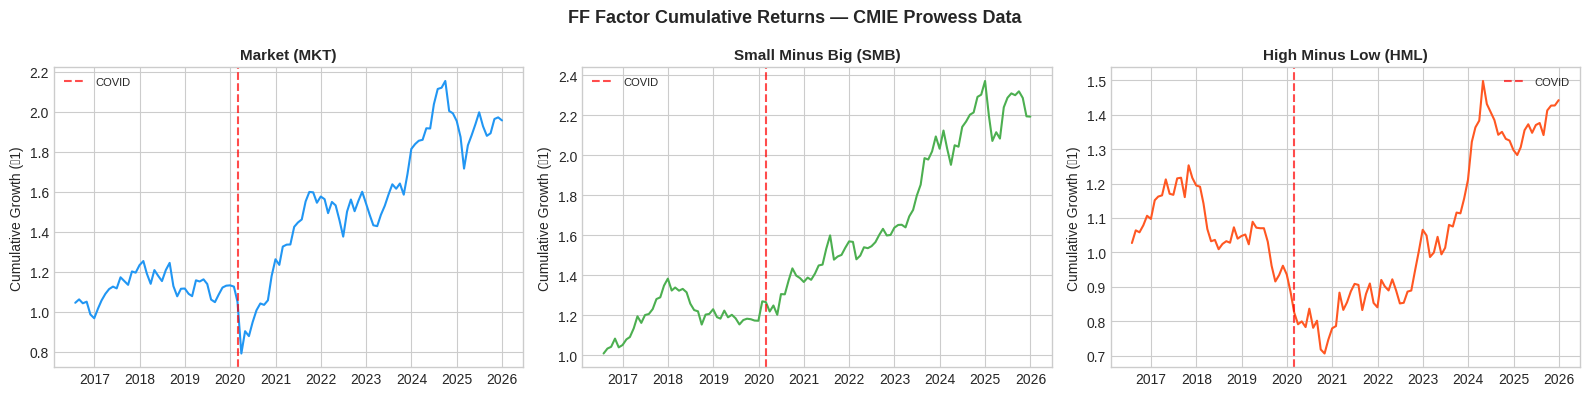

In [24]:
# ── Cumulative factor return plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = {'MKT': 'Market (MKT)', 'SMB': 'Small Minus Big (SMB)', 'HML': 'High Minus Low (HML)'}
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax, (col, title), color in zip(axes, labels.items(), colors):
    cum = (1 + factors[col]).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=1.5)
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.7, label='COVID')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative Growth (₹1)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('FF Factor Cumulative Returns — CMIE Prowess Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ff_factors_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7: Construct 9 Test Portfolios (3×3)

In [25]:
N_SIZE_GROUPS = 3
N_BM_GROUPS   = 3

def assign_test_portfolios(sort_df, n_size=3, n_bm=3):
    df = sort_df.copy()
    size_labels = [f'S{i+1}' for i in range(n_size)]
    bm_labels   = [f'BM{i+1}' for i in range(n_bm)]
    df['size_q'] = pd.qcut(df['mktcap'], n_size, labels=size_labels)
    df['bm_q']   = pd.qcut(df['bm'],     n_bm,   labels=bm_labels)
    df['test_port'] = df['size_q'].astype(str) + '_' + df['bm_q'].astype(str)
    return df


test_port_rows = []

for year, sort_df in sort_data_by_year.items():
    try:
        assigned = assign_test_portfolios(sort_df, N_SIZE_GROUPS, N_BM_GROUPS)
    except ValueError as e:
        print(f'Year {year}: qcut failed ({e}) — skipping.')
        continue

    july_start   = pd.Timestamp(f'{year}-07-01')
    june_end     = pd.Timestamp(f'{year+1}-06-30')
    period_dates = returns.index[(returns.index >= july_start) & (returns.index <= june_end)]

    for date in period_dates:
        row = {'Date': date}
        for port in assigned['test_port'].unique():
            stocks_in = assigned[assigned['test_port'] == port].index.tolist()
            wts = assigned.loc[[s for s in stocks_in if s in assigned.index], 'mktcap']
            row[port] = vw_return(stocks_in, wts, returns, date)
        test_port_rows.append(row)

test_ports  = pd.DataFrame(test_port_rows).set_index('Date').sort_index()
test_excess = test_ports.subtract(factors['Rf'], axis=0).dropna(how='all')
print(f'Test portfolio excess returns: {test_excess.shape}')

Test portfolio excess returns: (114, 9)


---
## Step 8: FF3 Regressions — Full Sample

In [26]:
def run_ff3_regression(excess_ret, factors_df):
    y = excess_ret.dropna()
    X = factors_df[['MKT', 'SMB', 'HML']].loc[y.index].dropna()
    y = y.loc[X.index]
    if len(y) < 24:
        return None
    model = sm.OLS(y, sm.add_constant(X)).fit(cov_type='HC3')
    return {
        'alpha':    model.params['const'],    'alpha_t': model.tvalues['const'],
        'beta_mkt': model.params['MKT'],      't_mkt':   model.tvalues['MKT'],
        'beta_smb': model.params['SMB'],      't_smb':   model.tvalues['SMB'],
        'beta_hml': model.params['HML'],      't_hml':   model.tvalues['HML'],
        'r2':       model.rsquared,           'adj_r2':  model.rsquared_adj,
        'n_obs':    len(y)
    }


reg_results = {}
for port in test_excess.columns:
    r = run_ff3_regression(test_excess[port], factors)
    if r:
        reg_results[port] = r

results_df = pd.DataFrame(reg_results).T.sort_index()
print(f'Regressions completed: {len(results_df)} portfolios')
print(results_df[['alpha', 'alpha_t', 'beta_mkt', 'beta_smb', 'beta_hml', 'r2', 'adj_r2']].round(4).to_string())

Regressions completed: 9 portfolios
         alpha  alpha_t  beta_mkt  beta_smb  beta_hml     r2  adj_r2
S1_BM1  0.0033   1.2494    0.9282    1.0091   -0.1003 0.8368  0.8324
S1_BM2  0.0030   1.3331    1.0267    0.9875    0.1416 0.8973  0.8945
S1_BM3  0.0012   0.5753    1.0488    0.9895    0.5605 0.9369  0.9352
S2_BM1 -0.0031  -1.9873    0.8854    0.5920   -0.1864 0.9019  0.8992
S2_BM2 -0.0014  -0.7681    0.9202    0.5768    0.0984 0.8890  0.8860
S2_BM3 -0.0040  -1.7621    0.9781    0.5128    0.8103 0.9190  0.9167
S3_BM1 -0.0020  -1.0061    0.9811   -0.1672   -0.2872 0.8777  0.8744
S3_BM2 -0.0001  -0.0851    0.9407   -0.1492    0.0576 0.8886  0.8856
S3_BM3 -0.0012  -0.7363    0.9419   -0.2401    0.7758 0.9333  0.9315


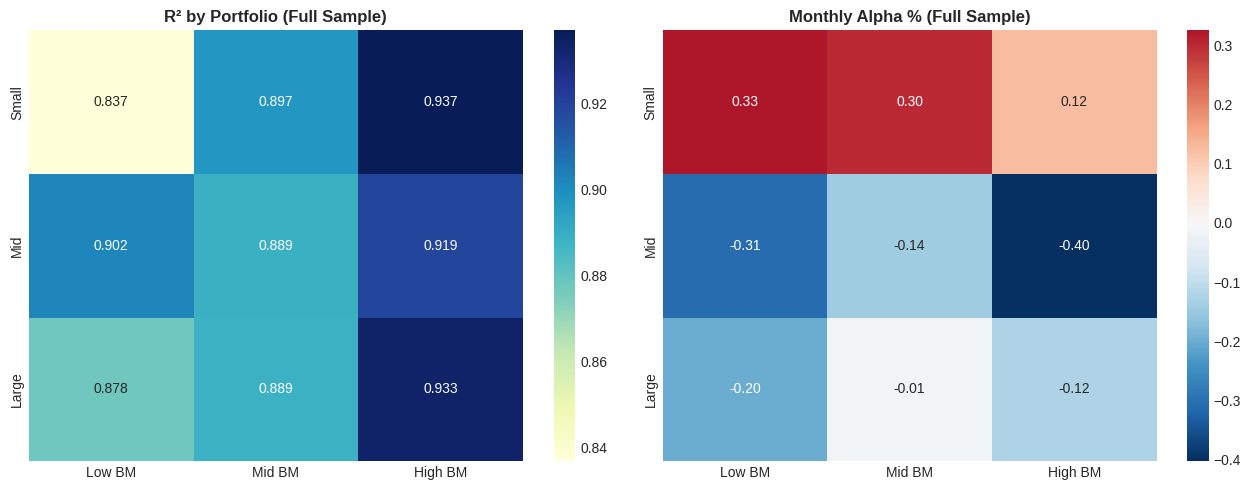

In [27]:
# ── Heatmaps: R² and Alpha ────────────────────────────────────────────────────
def pivot_results(results_df, metric, n_size=3, n_bm=3):
    size_labels = [f'S{i+1}' for i in range(n_size)]
    bm_labels   = [f'BM{i+1}' for i in range(n_bm)]
    mat = pd.DataFrame(index=size_labels, columns=bm_labels, dtype=float)
    for port in results_df.index:
        parts = port.split('_')
        if len(parts) == 2 and parts[0] in mat.index and parts[1] in mat.columns:
            mat.loc[parts[0], parts[1]] = results_df.loc[port, metric]
    return mat.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_results(results_df, 'r2'), annot=True, fmt='.3f',
            cmap='YlGnBu', ax=axes[0],
            xticklabels=['Low BM', 'Mid BM', 'High BM'],
            yticklabels=['Small', 'Mid', 'Large'])
axes[0].set_title('R² by Portfolio (Full Sample)', fontweight='bold')

sns.heatmap(pivot_results(results_df, 'alpha') * 100, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1],
            xticklabels=['Low BM', 'Mid BM', 'High BM'],
            yticklabels=['Small', 'Mid', 'Large'])
axes[1].set_title('Monthly Alpha % (Full Sample)', fontweight='bold')

plt.tight_layout()
plt.savefig('ff_heatmaps_full.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Pre-COVID vs Post-COVID Analysis

In [28]:
PERIOD_SPLITS = {
    'Pre-COVID':  (pd.Timestamp('2015-07-01'), pd.Timestamp('2020-02-28')),
    'Post-COVID': (pd.Timestamp('2020-04-01'), pd.Timestamp(END_DATE))
}

period_results = {}
for period_name, (start, end) in PERIOD_SPLITS.items():
    period_factors = factors.loc[start:end]
    period_excess  = test_excess.loc[start:end]

    period_reg = {}
    for port in period_excess.columns:
        r = run_ff3_regression(period_excess[port], period_factors)
        if r:
            period_reg[port] = r

    period_df = pd.DataFrame(period_reg).T.sort_index()
    period_results[period_name] = period_df

    print(f'\n--- {period_name}: {start.date()} to {end.date()} ---')
    print(f'  Portfolios : {len(period_df)}')
    print(f'  Mean R²    : {period_df["r2"].mean():.4f}')
    print(f'  Mean |α|   : {period_df["alpha"].abs().mean():.4f}')
    print(f'  Mean β_MKT : {period_df["beta_mkt"].mean():.4f}')
    print(f'  Mean β_SMB : {period_df["beta_smb"].mean():.4f}')
    print(f'  Mean β_HML : {period_df["beta_hml"].mean():.4f}')


--- Pre-COVID: 2015-07-01 to 2020-02-28 ---
  Portfolios : 9
  Mean R²    : 0.8822
  Mean |α|   : 0.0054
  Mean β_MKT : 0.9916
  Mean β_SMB : 0.4696
  Mean β_HML : 0.1203

--- Post-COVID: 2020-04-01 to 2026-03-27 ---
  Portfolios : 9
  Mean R²    : 0.8882
  Mean |α|   : 0.0033
  Mean β_MKT : 0.9889
  Mean β_SMB : 0.4478
  Mean β_HML : 0.2204


In [29]:
# ── Summary comparison table ──────────────────────────────────────────────────
summary_rows = []
for period, df in period_results.items():
    summary_rows.append({
        'Period':               period,
        'Portfolios':           len(df),
        'Mean R²':              df['r2'].mean(),
        'Mean Adj-R²':          df['adj_r2'].mean(),
        'Mean |α| (monthly)':   df['alpha'].abs().mean(),
        '% α sig (|t|>2)':      (df['alpha_t'].abs() > 2).mean() * 100,
        'Mean β_MKT':           df['beta_mkt'].mean(),
        'Mean β_SMB':           df['beta_smb'].mean(),
        'Mean β_HML':           df['beta_hml'].mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Period')
print('\n======= PRE vs POST COVID SUMMARY =======')
print(summary_df.round(4).to_string())


======= PRE vs POST COVID SUMMARY =======
            Portfolios  Mean R²  Mean Adj-R²  Mean |α| (monthly)  % α sig (|t|>2)  Mean β_MKT  Mean β_SMB  Mean β_HML
Period                                                                                                               
Pre-COVID            9   0.8822       0.8731              0.0054          44.4444      0.9916      0.4696      0.1203
Post-COVID           9   0.8882       0.8830              0.0033          11.1111      0.9889      0.4478      0.2204


---
## Step 10: Robustness Checks

In [30]:
# ── Robustness 1: Equal-Weighted vs Value-Weighted ────────────────────────────
def equal_weighted_return(stocks, returns_df, date):
    valid = [s for s in stocks if s in returns_df.columns]
    if not valid or date not in returns_df.index:
        return np.nan
    return returns_df.loc[date, valid].mean()


ew_port_rows = []
for year, sort_df in sort_data_by_year.items():
    try:
        assigned = assign_test_portfolios(sort_df, N_SIZE_GROUPS, N_BM_GROUPS)
    except ValueError:
        continue
    july_start   = pd.Timestamp(f'{year}-07-01')
    june_end     = pd.Timestamp(f'{year+1}-06-30')
    period_dates = returns.index[(returns.index >= july_start) & (returns.index <= june_end)]
    for date in period_dates:
        row = {'Date': date}
        for port in assigned['test_port'].unique():
            stocks_in = assigned[assigned['test_port'] == port].index.tolist()
            row[port] = equal_weighted_return(stocks_in, returns, date)
        ew_port_rows.append(row)

ew_ports  = pd.DataFrame(ew_port_rows).set_index('Date').sort_index()
ew_excess = ew_ports.subtract(factors['Rf'], axis=0).dropna(how='all')
ew_reg    = {port: run_ff3_regression(ew_excess[port], factors)
             for port in ew_excess.columns}
ew_results_df = pd.DataFrame({k: v for k, v in ew_reg.items() if v}).T

print('=== Robustness 1: EW vs VW ===')
print(f'  VW — Mean R²: {results_df["r2"].mean():.4f} | Mean |α|: {results_df["alpha"].abs().mean():.4f}')
print(f'  EW — Mean R²: {ew_results_df["r2"].mean():.4f} | Mean |α|: {ew_results_df["alpha"].abs().mean():.4f}')

=== Robustness 1: EW vs VW ===
  VW — Mean R²: 0.8978 | Mean |α|: 0.0022
  EW — Mean R²: 0.9019 | Mean |α|: 0.0034


In [31]:
# ── Robustness 2: CAPM vs FF3 ─────────────────────────────────────────────────
def run_capm_regression(excess_ret, factors_df):
    y = excess_ret.dropna()
    X = factors_df[['MKT']].loc[y.index].dropna()
    y = y.loc[X.index]
    if len(y) < 24:
        return None
    model = sm.OLS(y, sm.add_constant(X)).fit(cov_type='HC3')
    return {'alpha': model.params['const'], 'alpha_t': model.tvalues['const'],
            'beta_mkt': model.params['MKT'], 'r2': model.rsquared}


capm_reg = {port: run_capm_regression(test_excess[port], factors)
            for port in test_excess.columns}
capm_df  = pd.DataFrame({k: v for k, v in capm_reg.items() if v}).T

print('=== Robustness 2: CAPM vs FF3 ===')
print(f'  CAPM — Mean R²: {capm_df["r2"].mean():.4f} | Mean |α|: {capm_df["alpha"].abs().mean():.4f}')
print(f'  FF3  — Mean R²: {results_df["r2"].mean():.4f} | Mean |α|: {results_df["alpha"].abs().mean():.4f}')
print(f'  Avg R² gain FF3 over CAPM: {(results_df["r2"] - capm_df["r2"]).mean():.4f}')

=== Robustness 2: CAPM vs FF3 ===
  CAPM — Mean R²: 0.7445 | Mean |α|: 0.0040
  FF3  — Mean R²: 0.8978 | Mean |α|: 0.0022
  Avg R² gain FF3 over CAPM: 0.1534


---
## Step 11: Final Plots & Export

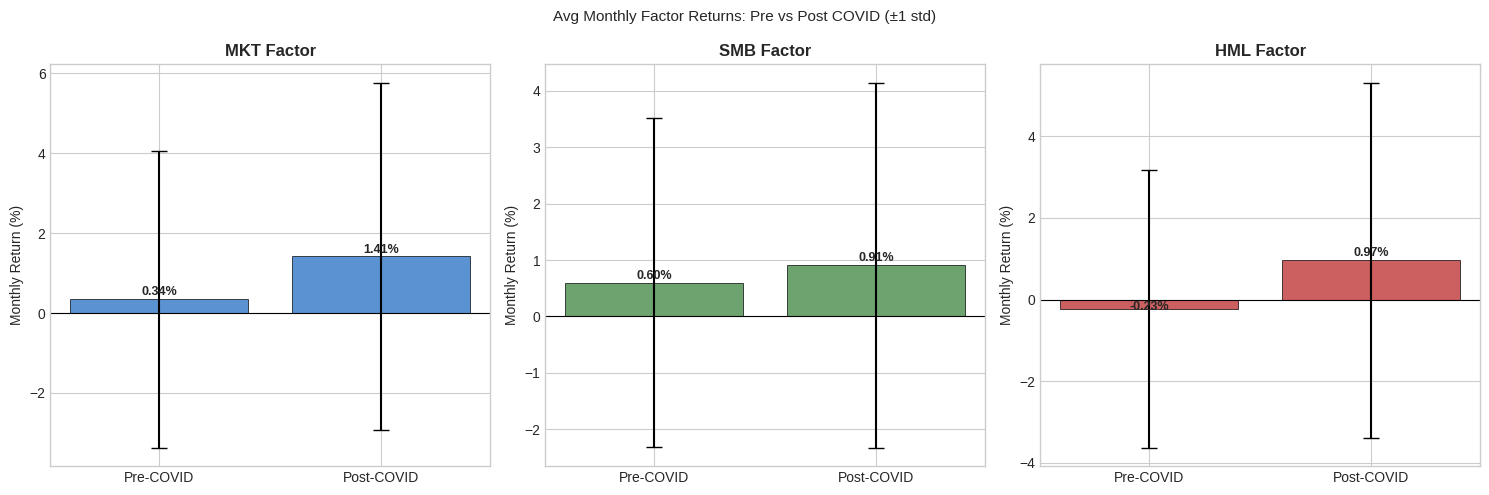

In [33]:
# ── Factor bar chart: Pre vs Post COVID ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, factor, color in zip(axes, ['MKT', 'SMB', 'HML'],
                              ['#1565C0', '#2E7D32', '#B71C1C']):
    pre_f  = factors.loc[PERIOD_SPLITS['Pre-COVID'][0]:PERIOD_SPLITS['Pre-COVID'][1], factor]
    post_f = factors.loc[PERIOD_SPLITS['Post-COVID'][0]:PERIOD_SPLITS['Post-COVID'][1], factor]
    means  = [pre_f.mean() * 100, post_f.mean() * 100]
    stds   = [pre_f.std()  * 100, post_f.std()  * 100]
    bars   = ax.bar(['Pre-COVID', 'Post-COVID'], means, yerr=stds, capsize=6,
                    color=[color, color], alpha=0.7,
                    edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{factor} Factor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Monthly Return (%)')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.02 if mean >= 0 else -0.1),
                f'{mean:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Avg Monthly Factor Returns: Pre vs Post COVID (±1 std)', fontsize=11)
plt.tight_layout()
plt.savefig('ff_factor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ── Save all results ──────────────────────────────────────────────────────────
with pd.ExcelWriter('fama_french_india_results.xlsx', engine='openpyxl') as writer:
    factors.to_excel(writer, sheet_name='Factors')
    results_df.to_excel(writer, sheet_name='FF3_Full_Sample')
    period_results['Pre-COVID'].to_excel(writer, sheet_name='FF3_Pre_COVID')
    period_results['Post-COVID'].to_excel(writer, sheet_name='FF3_Post_COVID')
    summary_df.to_excel(writer, sheet_name='Summary')
    capm_df.to_excel(writer, sheet_name='CAPM_Full_Sample')
    ew_results_df.to_excel(writer, sheet_name='FF3_EqualWeighted')

print('Results saved to fama_french_india_results.xlsx')

Results saved to fama_french_india_results.xlsx


---
## Interpretation Guide

| Metric | What it means |
|---|---|
| **R² (FF3 > CAPM)** | FF3 explains more return variation than CAPM alone |
| **α ≈ 0** | 3 factors adequately price the portfolios |
| **β_SMB > 0 for small stocks** | Size premium present |
| **β_HML > 0 for high BM stocks** | Value premium present |
| **Post-COVID SMB change** | Size premium dynamics shifted post-2020 |
| **Post-COVID HML change** | Value vs growth rotation — global phenomenon |

### Limitations to state in your report:
1. **Survivorship bias** — CMIE CSV covers 320 continuously-traded stocks only
2. **Market index** — NIFTY 500 from yfinance used for market return (single ticker, reliable)
3. **3×3 portfolios** — 25 would give <15 stocks/cell with 320-stock universe
4. **BV timing** — December extraction is look-ahead free for March FY-end companies; non-March FY-end companies (e.g. Dec, June) may still have slight timing approximation
5. **RF rate lag** — FRED data has ~2 month lag; recent months forward-filled

---
*Methodology follows Fama & French (1993). Data: CMIE Prowess + FRED + Yahoo Finance.*

In [35]:
import subprocess, sys
for pkg in ['scipy', 'statsmodels', 'matplotlib', 'seaborn', 'pandas', 'numpy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Verify required variables exist ──────────────────────────────────────────
required = ['factors', 'test_excess', 'results_df', 'period_results', 'PERIOD_SPLITS']
missing  = [v for v in required if v not in dir()]
if missing:
    print(f'⚠️  Missing variables: {missing}')
    print('Run the main FF3 notebook first, then run this one.')
else:
    print('✓ All required variables found.')
    print(f'  factors shape    : {factors.shape}  ({factors.index[0].date()} → {factors.index[-1].date()})')
    print(f'  test_excess shape: {test_excess.shape}')
    print(f'  Portfolios       : {list(test_excess.columns)}')
    print(f'  Periods          : {list(period_results.keys())}')

✓ All required variables found.
  factors shape    : (114, 4)  (2016-07-31 → 2025-12-31)
  test_excess shape: (114, 9)
  Portfolios       : ['S3_BM2', 'S3_BM3', 'S2_BM2', 'S1_BM3', 'S1_BM2', 'S2_BM3', 'S2_BM1', 'S3_BM1', 'S1_BM1']
  Periods          : ['Pre-COVID', 'Post-COVID']


In [36]:
# Section 1 — Full Regression Tables with Standard Errors
# For each portfolio and each period, shows:
# Coefficient | Std Error | t-statistic | p-value | 95% CI | Stars

def full_regression_table(excess_ret_df, factors_df, label='Full Sample'):
    """
    Run FF3 OLS with HC3-robust SEs for every portfolio.
    Returns a tidy DataFrame with one row per (portfolio, variable).
    """
    rows = []
    for port in excess_ret_df.columns:
        y = excess_ret_df[port].dropna()
        X = factors_df[['MKT', 'SMB', 'HML']].loc[y.index].dropna()
        y = y.loc[X.index]
        if len(y) < 24:
            continue
        model = sm.OLS(y, sm.add_constant(X)).fit(cov_type='HC3')

        for var in ['const', 'MKT', 'SMB', 'HML']:
            coef   = model.params[var]
            se     = model.bse[var]
            tstat  = model.tvalues[var]
            pval   = model.pvalues[var]
            ci_lo  = model.conf_int().loc[var, 0]
            ci_hi  = model.conf_int().loc[var, 1]
            stars  = ('***' if pval < 0.01 else
                      '**'  if pval < 0.05 else
                      '*'   if pval < 0.10 else '')
            rows.append({
                'Period':    label,
                'Portfolio': port,
                'Variable':  var.replace('const', 'Alpha'),
                'Coef':      coef,
                'Std_Err':   se,
                't_stat':    tstat,
                'p_value':   pval,
                'CI_95_Lo':  ci_lo,
                'CI_95_Hi':  ci_hi,
                'Sig':       stars,
                'R2':        model.rsquared,
                'Adj_R2':    model.rsquared_adj,
                'N':         len(y),
            })
    return pd.DataFrame(rows)


# Build tables for all three periods
pre_start,  pre_end  = PERIOD_SPLITS['Pre-COVID']
post_start, post_end = PERIOD_SPLITS['Post-COVID']

tbl_full = full_regression_table(test_excess, factors, 'Full Sample')
tbl_pre  = full_regression_table(
    test_excess.loc[pre_start:pre_end], factors.loc[pre_start:pre_end], 'Pre-COVID')
tbl_post = full_regression_table(
    test_excess.loc[post_start:post_end], factors.loc[post_start:post_end], 'Post-COVID')

all_tables = pd.concat([tbl_full, tbl_pre, tbl_post], ignore_index=True)

print('Significance key:  *** p<0.01   ** p<0.05   * p<0.10')
print('Standard errors: HC3 heteroskedasticity-robust\n')
print('='*80)
print('FULL SAMPLE — ALPHA ROWS ONLY')
print('='*80)
alpha_full = tbl_full[tbl_full['Variable'] == 'Alpha'].set_index('Portfolio')
print(alpha_full[['Coef','Std_Err','t_stat','p_value','CI_95_Lo','CI_95_Hi','Sig','R2','N']]
      .rename(columns={'Coef':'α','Std_Err':'SE(α)','t_stat':'t','p_value':'p',
                       'CI_95_Lo':'CI Lo','CI_95_Hi':'CI Hi'})
      .round(4).to_string())

Significance key:  *** p<0.01   ** p<0.05   * p<0.10
Standard errors: HC3 heteroskedasticity-robust

FULL SAMPLE — ALPHA ROWS ONLY
                α  SE(α)       t      p   CI Lo   CI Hi Sig     R2    N
Portfolio                                                              
S3_BM2    -0.0001 0.0015 -0.0851 0.9322 -0.0031  0.0029     0.8886  114
S3_BM3    -0.0012 0.0017 -0.7363 0.4616 -0.0045  0.0021     0.9333  114
S2_BM2    -0.0014 0.0019 -0.7681 0.4424 -0.0051  0.0022     0.8890  114
S1_BM3     0.0012 0.0021  0.5753 0.5651 -0.0030  0.0054     0.9369  114
S1_BM2     0.0030 0.0022  1.3331 0.1825 -0.0014  0.0074     0.8973  114
S2_BM3    -0.0040 0.0023 -1.7621 0.0781 -0.0085  0.0005   * 0.9190  114
S2_BM1    -0.0031 0.0015 -1.9873 0.0469 -0.0061 -0.0000  ** 0.9019  114
S3_BM1    -0.0020 0.0020 -1.0061 0.3144 -0.0059  0.0019     0.8777  114
S1_BM1     0.0033 0.0026  1.2494 0.2115 -0.0019  0.0084     0.8368  114


In [37]:
# ── Print full table for each portfolio (publication-style) ───────────────────
print('FULL SAMPLE — ALL COEFFICIENTS BY PORTFOLIO')
print('='*80)

for port in sorted(tbl_full['Portfolio'].unique()):
    sub = tbl_full[tbl_full['Portfolio'] == port].set_index('Variable')
    r2  = sub['R2'].iloc[0]
    n   = int(sub['N'].iloc[0])
    print(f'\nPortfolio: {port}   R²={r2:.4f}   N={n}')
    print(f"  {'Variable':<8} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8} {'95% CI':>22} Sig")
    print('  ' + '-'*72)
    for var in ['Alpha', 'MKT', 'SMB', 'HML']:
        if var not in sub.index:
            continue
        r = sub.loc[var]
        ci_str = f'[{r["CI_95_Lo"]:+.4f}, {r["CI_95_Hi"]:+.4f}]'
        print(f"  {var:<8} {r['Coef']:>10.4f} {r['Std_Err']:>10.4f} "
              f"{r['t_stat']:>8.3f} {r['p_value']:>8.4f} {ci_str:>22} {r['Sig']}")

FULL SAMPLE — ALL COEFFICIENTS BY PORTFOLIO

Portfolio: S1_BM1   R²=0.8368   N=114
  Variable       Coef         SE        t        p                 95% CI Sig
  ------------------------------------------------------------------------
  Alpha        0.0033     0.0026    1.249   0.2115     [-0.0019, +0.0084] 
  MKT          0.9282     0.0658   14.107   0.0000     [+0.7992, +1.0571] ***
  SMB          1.0091     0.0828   12.189   0.0000     [+0.8468, +1.1714] ***
  HML         -0.1003     0.0676   -1.483   0.1382     [-0.2329, +0.0323] 

Portfolio: S1_BM2   R²=0.8973   N=114
  Variable       Coef         SE        t        p                 95% CI Sig
  ------------------------------------------------------------------------
  Alpha        0.0030     0.0022    1.333   0.1825     [-0.0014, +0.0074] 
  MKT          1.0267     0.0469   21.892   0.0000     [+0.9347, +1.1186] ***
  SMB          0.9875     0.0774   12.755   0.0000     [+0.8357, +1.1392] ***
  HML          0.1416     0.0736   

In [38]:
def factor_significance_summary(tbl_df):
    """Summarise factor significance across portfolios."""
    results = []
    period  = tbl_df['Period'].iloc[0]

    for factor in ['MKT', 'SMB', 'HML']:
        sub = tbl_df[tbl_df['Variable'] == factor]
        results.append({
            'Period':          period,
            'Factor':          factor,
            'Mean_Coef':       sub['Coef'].mean(),
            'Std_Coef':        sub['Coef'].std(),
            'Mean_SE':         sub['Std_Err'].mean(),
            'Mean_t':          sub['t_stat'].mean(),
            'Min_t':           sub['t_stat'].min(),
            'Max_t':           sub['t_stat'].max(),
            'Pct_Sig_1pct':    (sub['p_value'] < 0.01).mean() * 100,
            'Pct_Sig_5pct':    (sub['p_value'] < 0.05).mean() * 100,
            'Pct_Sig_10pct':   (sub['p_value'] < 0.10).mean() * 100,
            'All_Positive':    (sub['Coef'] > 0).all(),
            'All_Negative':    (sub['Coef'] < 0).all(),
        })
    return pd.DataFrame(results).set_index(['Period','Factor'])

sig_full = factor_significance_summary(tbl_full)
sig_pre  = factor_significance_summary(tbl_pre)
sig_post = factor_significance_summary(tbl_post)
sig_all  = pd.concat([sig_full, sig_pre, sig_post])

print('FACTOR SIGNIFICANCE SUMMARY (across 9 test portfolios)')
print('Pct_Sig_Xpct = % of portfolios where factor is significant at X% level')
print('='*80)
cols = ['Mean_Coef','Std_Coef','Mean_SE','Mean_t','Pct_Sig_1pct','Pct_Sig_5pct','Pct_Sig_10pct']
print(sig_all[cols].round(4).to_string())

FACTOR SIGNIFICANCE SUMMARY (across 9 test portfolios)
Pct_Sig_Xpct = % of portfolios where factor is significant at X% level
                    Mean_Coef  Std_Coef  Mean_SE  Mean_t  Pct_Sig_1pct  Pct_Sig_5pct  Pct_Sig_10pct
Period      Factor                                                                                 
Full Sample MKT        0.9612    0.0524   0.0591 17.8746      100.0000      100.0000       100.0000
            SMB        0.4568    0.5182   0.0631  6.4916      100.0000      100.0000       100.0000
            HML        0.2078    0.4099   0.0552  3.6347       55.5556       55.5556        77.7778
Pre-COVID   MKT        0.9916    0.1127   0.1018 10.0322      100.0000      100.0000       100.0000
            SMB        0.4696    0.5205   0.0978  4.3169       88.8889       88.8889        88.8889
            HML        0.1203    0.4341   0.1059  0.7133       55.5556       55.5556        55.5556
Post-COVID  MKT        0.9889    0.0721   0.0701 14.8317      100.0000    

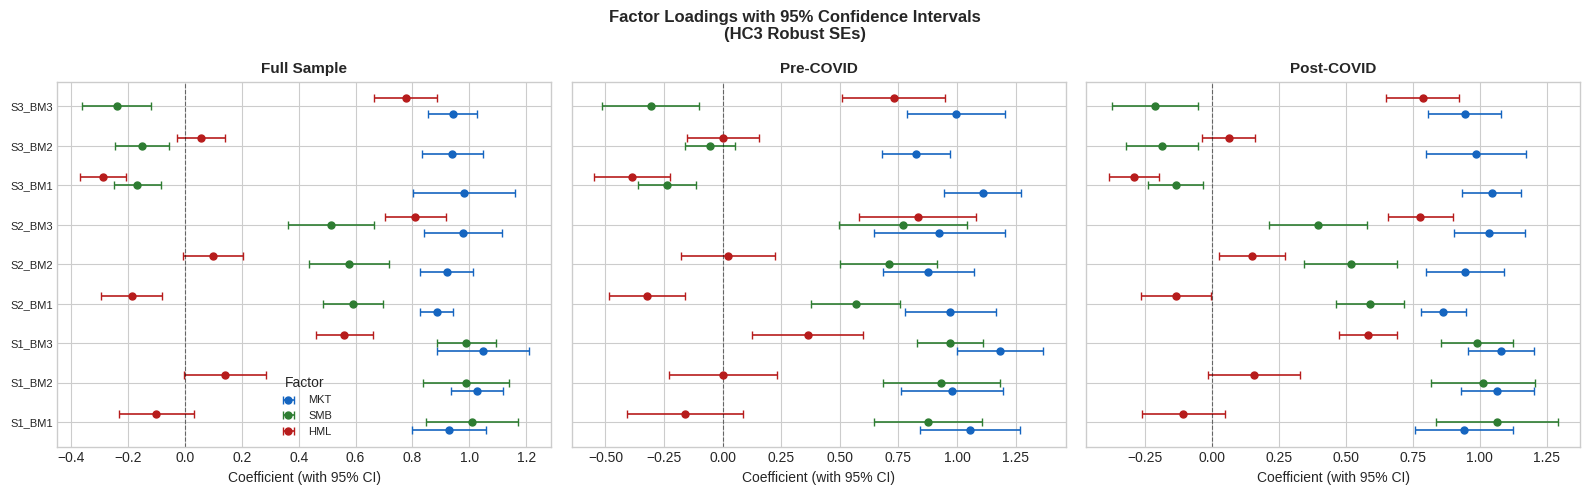

In [39]:
# ── Visual: coefficient dot plot with confidence intervals ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
periods_plot = [('Full Sample', tbl_full), ('Pre-COVID', tbl_pre), ('Post-COVID', tbl_post)]
factor_colors = {'MKT': '#1565C0', 'SMB': '#2E7D32', 'HML': '#B71C1C'}

for ax, (period_label, tbl) in zip(axes, periods_plot):
    portfolios = sorted(tbl['Portfolio'].unique())
    y_positions = {p: i for i, p in enumerate(portfolios)}

    for factor, color in factor_colors.items():
        sub = tbl[tbl['Variable'] == factor]
        for _, row in sub.iterrows():
            y = y_positions[row['Portfolio']]
            offset = {'MKT': -0.2, 'SMB': 0.0, 'HML': 0.2}[factor]
            ax.errorbar(row['Coef'], y + offset,
                        xerr=[[row['Coef'] - row['CI_95_Lo']],
                              [row['CI_95_Hi'] - row['Coef']]],
                        fmt='o', color=color, markersize=5,
                        capsize=3, linewidth=1.2,
                        label=factor if row['Portfolio'] == portfolios[0] else '')

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(portfolios)))
    ax.set_yticklabels(portfolios, fontsize=8)
    ax.set_title(period_label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Coefficient (with 95% CI)')
    if ax == axes[0]:
        ax.legend(title='Factor', fontsize=8)

plt.suptitle('Factor Loadings with 95% Confidence Intervals\n(HC3 Robust SEs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diag_coef_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
def grs_test(excess_ret_df, factors_df):
    """
    Gibbons, Ross & Shanken (1989) GRS F-statistic.

    Formula:
        GRS = [(T-N-K)/N] * [1 + E(f)'Σ_f^{-1}E(f)]^{-1} * α'Σ_ε^{-1}α
        ~ F(N, T-N-K) under H0

    where:
        T = number of time-series observations
        N = number of test portfolios
        K = number of factors
        α = vector of OLS alphas
        Σ_ε = covariance matrix of residuals
        Σ_f = covariance matrix of factors
        E(f) = mean factor returns
    """
    factor_cols = ['MKT', 'SMB', 'HML']

    # Align data
    common_idx = excess_ret_df.dropna(how='all').index.intersection(
        factors_df.dropna().index)
    Y = excess_ret_df.loc[common_idx].dropna(axis=1)
    F = factors_df.loc[common_idx, factor_cols]

    T = len(Y)
    N = Y.shape[1]
    K = len(factor_cols)

    # Run OLS for each portfolio
    alphas   = np.zeros(N)
    residuals = np.zeros((T, N))

    X = sm.add_constant(F.values)
    for i, col in enumerate(Y.columns):
        model = sm.OLS(Y[col].values, X).fit()
        alphas[i]       = model.params[0]
        residuals[:, i] = model.resid

    # Residual covariance matrix (T denominator)
    Sigma_eps = np.cov(residuals.T, ddof=K+1)

    # Factor covariance matrix and mean
    mu_f    = F.mean().values
    Sigma_f = np.cov(F.values.T)

    # Sharpe ratio adjustment
    sh_adj = float(mu_f @ np.linalg.inv(Sigma_f) @ mu_f)

    # GRS statistic
    Sigma_eps_inv = np.linalg.inv(Sigma_eps)
    quad_form     = float(alphas @ Sigma_eps_inv @ alphas)
    grs_stat      = ((T - N - K) / N) * quad_form / (1 + sh_adj)

    # p-value from F distribution
    df1   = N
    df2   = T - N - K
    pval  = 1 - stats.f.cdf(grs_stat, df1, df2)

    return {
        'GRS_stat':    grs_stat,
        'p_value':     pval,
        'df1':         df1,
        'df2':         df2,
        'N_portfolios': N,
        'T_obs':        T,
        'mean_alpha':   alphas.mean(),
        'mean_abs_alpha': np.abs(alphas).mean(),
        'sh_adj_factor':  sh_adj,
        'reject_H0_5pct': pval < 0.05
    }


grs_results = {}
for label, exc, fac in [
    ('Full Sample', test_excess, factors),
    ('Pre-COVID',   test_excess.loc[pre_start:pre_end],  factors.loc[pre_start:pre_end]),
    ('Post-COVID',  test_excess.loc[post_start:post_end], factors.loc[post_start:post_end])
]:
    grs_results[label] = grs_test(exc, fac)

grs_df = pd.DataFrame(grs_results).T

print('='*65)
print('GRS TEST — H₀: ALL PORTFOLIO ALPHAS ARE JOINTLY ZERO')
print('='*65)
print(f"{'Period':<15} {'GRS F-stat':>12} {'p-value':>10} {'df1/df2':>12} {'|α| mean':>10} {'Reject H₀?':>12}")
print('-'*65)
for period, row in grs_df.iterrows():
    reject = '✗ YES' if row['reject_H0_5pct'] else '✓ NO'
    df_str = f"{int(row['df1'])}/{int(row['df2'])}"
    print(f"{period:<15} {row['GRS_stat']:>12.4f} {row['p_value']:>10.4f} "
          f"{df_str:>12} {row['mean_abs_alpha']:>10.4f} {reject:>12}")
print()
print('Interpretation:')
print('  ✓ NO  = Cannot reject H₀ → alphas collectively consistent with zero → model valid')
print('  ✗ YES = Reject H₀ → significant joint mispricing → model incomplete')

GRS TEST — H₀: ALL PORTFOLIO ALPHAS ARE JOINTLY ZERO
Period            GRS F-stat    p-value      df1/df2   |α| mean   Reject H₀?
-----------------------------------------------------------------
Full Sample           2.0354     0.0426        9/102     0.0022        ✗ YES
Pre-COVID             2.6190     0.0223         9/31     0.0054        ✗ YES
Post-COVID            2.4458     0.0198         9/57     0.0033        ✗ YES

Interpretation:
  ✓ NO  = Cannot reject H₀ → alphas collectively consistent with zero → model valid
  ✗ YES = Reject H₀ → significant joint mispricing → model incomplete


In [42]:
def residual_diagnostics(excess_ret_df, factors_df, label):
    rows = []
    factor_cols = ['MKT', 'SMB', 'HML']

    for port in sorted(excess_ret_df.columns):
        y = excess_ret_df[port].dropna()
        X = factors_df[factor_cols].loc[y.index].dropna()
        y = y.loc[X.index]
        if len(y) < 24:
            continue

        model  = sm.OLS(y, sm.add_constant(X)).fit()
        resid  = model.resid
        X_vals = model.model.exog

        # Durbin-Watson
        dw = durbin_watson(resid)

        # Ljung-Box (lag 12)
        lb_result = acorr_ljungbox(resid, lags=[12], return_df=True)
        lb_stat   = lb_result['lb_stat'].iloc[0]
        lb_pval   = lb_result['lb_pvalue'].iloc[0]

        # Breusch-Pagan (heteroskedasticity)
        bp_stat, bp_pval, _, _ = het_breuschpagan(resid, X_vals)

        # Jarque-Bera (normality)
        jb_stat, jb_pval, skew, kurt = jarque_bera(resid)

        rows.append({
            'Period':        label,
            'Portfolio':     port,
            'N':             len(y),
            'DW_stat':       dw,
            'DW_ok':         1.5 <= dw <= 2.5,
            'LjungBox_stat': lb_stat,
            'LjungBox_pval': lb_pval,
            'LB_no_autocorr': lb_pval > 0.05,
            'BP_stat':       bp_stat,
            'BP_pval':       bp_pval,
            'BP_homosked':   bp_pval > 0.05,
            'JB_stat':       jb_stat,
            'JB_pval':       jb_pval,
            'JB_normal':     jb_pval > 0.05,
            'Skewness':      skew,
            'Kurtosis':      kurt,
        })
    return pd.DataFrame(rows)


diag_full = residual_diagnostics(test_excess, factors, 'Full Sample')
diag_pre  = residual_diagnostics(
    test_excess.loc[pre_start:pre_end], factors.loc[pre_start:pre_end], 'Pre-COVID')
diag_post = residual_diagnostics(
    test_excess.loc[post_start:post_end], factors.loc[post_start:post_end], 'Post-COVID')

diag_all = pd.concat([diag_full, diag_pre, diag_post], ignore_index=True)

print('RESIDUAL DIAGNOSTICS — FULL SAMPLE')
print('DW ~2.0 = no autocorrelation | LB p>0.05 = no autocorrelation')
print('BP p>0.05 = homoskedastic   | JB p>0.05 = normally distributed')
print('='*90)
disp_cols = ['Portfolio','N','DW_stat','DW_ok','LjungBox_pval','LB_no_autocorr',
             'BP_pval','BP_homosked','JB_pval','JB_normal','Skewness','Kurtosis']
print(diag_full[disp_cols].set_index('Portfolio').round(4).to_string())

print('\n--- DIAGNOSTIC PASS RATES ---')
for label, df in [('Full Sample', diag_full), ('Pre-COVID', diag_pre), ('Post-COVID', diag_post)]:
    dw_ok = df['DW_ok'].mean()*100
    lb_ok = df['LB_no_autocorr'].mean()*100
    bp_ok = df['BP_homosked'].mean()*100
    jb_ok = df['JB_normal'].mean()*100
    print(f'{label:<15}: DW={dw_ok:.0f}%  LB={lb_ok:.0f}%  BP={bp_ok:.0f}%  JB={jb_ok:.0f}%')

RESIDUAL DIAGNOSTICS — FULL SAMPLE
DW ~2.0 = no autocorrelation | LB p>0.05 = no autocorrelation
BP p>0.05 = homoskedastic   | JB p>0.05 = normally distributed
             N  DW_stat  DW_ok  LjungBox_pval  LB_no_autocorr  BP_pval  BP_homosked  JB_pval  JB_normal  Skewness  Kurtosis
Portfolio                                                                                                                  
S1_BM1     114   2.1360   True         0.2571            True   0.4322         True   0.0000      False    0.6380    5.6219
S1_BM2     114   1.5896   True         0.0000           False   0.5530         True   0.1620       True    0.4376    3.0120
S1_BM3     114   2.0906   True         0.2073            True   0.3540         True   0.1276       True    0.2772    3.7481
S2_BM1     114   1.8018   True         0.8048            True   0.1480         True   0.0009      False    0.7297    3.9136
S2_BM2     114   1.9220   True         0.0109           False   0.2027         True   0.9648    

In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PERIODS = {
    'Full Sample': (factors.index[0],               factors.index[-1]),
    'Pre-COVID':   PERIOD_SPLITS['Pre-COVID'],
    'Post-COVID':  PERIOD_SPLITS['Post-COVID'],
}

rows = []
for period_name, (start, end) in PERIODS.items():
    fac  = factors.loc[start:end]
    exc  = test_excess.loc[start:end]

    for port in sorted(exc.columns):
        y = exc[port].dropna()
        X = fac[['MKT','SMB','HML']].loc[y.index].dropna()
        y = y.loc[X.index]
        if len(y) < 24:
            continue

        m = sm.OLS(y, sm.add_constant(X)).fit()

        rows.append({
            'Period':    period_name,
            'Portfolio': port,
            'N':         len(y),
            'F_stat':    m.fvalue,
            'F_pvalue':  m.f_pvalue,
            'R2':        m.rsquared,
            'Adj_R2':    m.rsquared_adj,
            'Sig':       '***' if m.f_pvalue < 0.01 else
                         '**'  if m.f_pvalue < 0.05 else
                         '*'   if m.f_pvalue < 0.10 else 'ns',
            'Model_Valid': m.f_pvalue < 0.05,
        })

fstat_df = pd.DataFrame(rows)

print('FF3 MODEL F-STATISTICS — ALL PERIODS & PORTFOLIOS')
print('H₀: MKT = SMB = HML = 0   |   Reject → model is valid')
print('='*72)
print(f"{'Period':<14} {'Portfolio':<12} {'N':>5} {'F-stat':>10} {'p-value':>10} {'R²':>7} {'Adj-R²':>8} {'Sig':>5}")
print('-'*72)

prev_period = None
for _, r in fstat_df.iterrows():
    if r['Period'] != prev_period:
        if prev_period is not None:
            print()
        prev_period = r['Period']
    print(f"{r['Period']:<14} {r['Portfolio']:<12} {int(r['N']):>5} "
          f"{r['F_stat']:>10.2f} {r['F_pvalue']:>10.4f} "
          f"{r['R2']:>7.4f} {r['Adj_R2']:>8.4f} {r['Sig']:>5}")

print('\n' + '='*72)
summary = (fstat_df.groupby('Period')
           .agg(
               Portfolios = ('Portfolio', 'count'),
               Pct_Valid  = ('Model_Valid', lambda x: f"{x.mean()*100:.0f}%"),
               Mean_F     = ('F_stat', 'mean'),
               Min_F      = ('F_stat', 'min'),
               Mean_R2    = ('R2',     'mean'),
               Mean_AdjR2 = ('Adj_R2', 'mean'),
           )
           .reindex(['Full Sample','Pre-COVID','Post-COVID']))
print(summary.round(2).to_string())

FF3 MODEL F-STATISTICS — ALL PERIODS & PORTFOLIOS
H₀: MKT = SMB = HML = 0   |   Reject → model is valid
Period         Portfolio        N     F-stat    p-value      R²   Adj-R²   Sig
------------------------------------------------------------------------
Full Sample    S1_BM1         114     188.02     0.0000  0.8368   0.8324   ***
Full Sample    S1_BM2         114     320.38     0.0000  0.8973   0.8945   ***
Full Sample    S1_BM3         114     544.71     0.0000  0.9369   0.9352   ***
Full Sample    S2_BM1         114     337.01     0.0000  0.9019   0.8992   ***
Full Sample    S2_BM2         114     293.75     0.0000  0.8890   0.8860   ***
Full Sample    S2_BM3         114     415.73     0.0000  0.9190   0.9167   ***
Full Sample    S3_BM1         114     263.15     0.0000  0.8777   0.8744   ***
Full Sample    S3_BM2         114     292.62     0.0000  0.8886   0.8856   ***
Full Sample    S3_BM3         114     512.99     0.0000  0.9333   0.9315   ***

Pre-COVID      S1_BM1          4

In [44]:
print(grs_df2.round(4).to_string())

NameError: name 'grs_df2' is not defined

In [45]:
def compute_vif(factors_df, label):
    """
    Compute Variance Inflation Factor for each factor.
    VIF < 5 = acceptable | VIF 5-10 = moderate | VIF > 10 = severe multicollinearity
    """
    X = sm.add_constant(factors_df[['MKT', 'SMB', 'HML']].dropna())
    vif_data = {
        'Factor': ['MKT', 'SMB', 'HML'],
        'VIF':    [variance_inflation_factor(X.values, i+1) for i in range(3)]
    }
    df = pd.DataFrame(vif_data)
    df['Severity'] = df['VIF'].apply(
        lambda v: 'OK (<5)' if v < 5 else ('Moderate (5-10)' if v < 10 else 'Severe (>10)'))
    df.insert(0, 'Period', label)
    return df

vif_full = compute_vif(factors, 'Full Sample')
vif_pre  = compute_vif(factors.loc[pre_start:pre_end],  'Pre-COVID')
vif_post = compute_vif(factors.loc[post_start:post_end], 'Post-COVID')

print('VARIANCE INFLATION FACTORS (VIF)')
print('Rule: VIF < 5 = no problem, 5-10 = worth noting, >10 = serious multicollinearity')
print('='*55)
print(pd.concat([vif_full, vif_pre, vif_post], ignore_index=True)
      .set_index(['Period','Factor']).round(3).to_string())

# ── Factor correlation matrices ───────────────────────────────────────────────
print('\n\nFACTOR CORRELATION MATRICES')
for label, fac_df in [
    ('Full Sample', factors),
    ('Pre-COVID',   factors.loc[pre_start:pre_end]),
    ('Post-COVID',  factors.loc[post_start:post_end])
]:
    corr = fac_df[['MKT','SMB','HML']].corr()
    print(f'\n{label}  (N={len(fac_df)})')
    print(corr.round(4).to_string())

VARIANCE INFLATION FACTORS (VIF)
Rule: VIF < 5 = no problem, 5-10 = worth noting, >10 = serious multicollinearity
                      VIF Severity
Period      Factor                
Full Sample MKT    1.2200  OK (<5)
            SMB    1.0690  OK (<5)
            HML    1.1620  OK (<5)
Pre-COVID   MKT    1.3000  OK (<5)
            SMB    1.1050  OK (<5)
            HML    1.1860  OK (<5)
Post-COVID  MKT    1.1320  OK (<5)
            SMB    1.0320  OK (<5)
            HML    1.1180  OK (<5)


FACTOR CORRELATION MATRICES

Full Sample  (N=114)
       MKT    SMB    HML
MKT 1.0000 0.2522 0.3715
SMB 0.2522 1.0000 0.1280
HML 0.3715 0.1280 1.0000

Pre-COVID  (N=43)
       MKT    SMB    HML
MKT 1.0000 0.3049 0.3932
SMB 0.3049 1.0000 0.0769
HML 0.3932 0.0769 1.0000

Post-COVID  (N=69)
       MKT    SMB    HML
MKT 1.0000 0.1621 0.3172
SMB 0.1621 1.0000 0.1188
HML 0.3172 0.1188 1.0000


In [46]:
def compare_se_methods(excess_ret_df, factors_df, label):
    """
    For each portfolio: compare alpha SE under OLS, HC3, and Newey-West (HAC).
    Newey-West uses 4 lags (standard choice for monthly data: lags ≈ T^(1/4)).
    """
    rows = []
    for port in sorted(excess_ret_df.columns):
        y = excess_ret_df[port].dropna()
        X = factors_df[['MKT','SMB','HML']].loc[y.index].dropna()
        y = y.loc[X.index]
        if len(y) < 24:
            continue
        Xc = sm.add_constant(X)

        m_ols = sm.OLS(y, Xc).fit()
        m_hc3 = sm.OLS(y, Xc).fit(cov_type='HC3')
        m_nw  = sm.OLS(y, Xc).fit(cov_type='HAC',
                                    cov_kwds={'maxlags': int(len(y)**0.25)})

        rows.append({
            'Period':       label,
            'Portfolio':    port,
            'Alpha_OLS':    m_ols.params['const'],
            'SE_OLS':       m_ols.bse['const'],
            't_OLS':        m_ols.tvalues['const'],
            'p_OLS':        m_ols.pvalues['const'],
            'SE_HC3':       m_hc3.bse['const'],
            't_HC3':        m_hc3.tvalues['const'],
            'p_HC3':        m_hc3.pvalues['const'],
            'SE_NW':        m_nw.bse['const'],
            't_NW':         m_nw.tvalues['const'],
            'p_NW':         m_nw.pvalues['const'],
            'SE_HC3_vs_OLS': m_hc3.bse['const'] / m_ols.bse['const'],
            'SE_NW_vs_OLS':  m_nw.bse['const']  / m_ols.bse['const'],
        })
    return pd.DataFrame(rows)


se_full = compare_se_methods(test_excess, factors, 'Full Sample')
se_pre  = compare_se_methods(
    test_excess.loc[pre_start:pre_end], factors.loc[pre_start:pre_end], 'Pre-COVID')
se_post = compare_se_methods(
    test_excess.loc[post_start:post_end], factors.loc[post_start:post_end], 'Post-COVID')

print('SE METHOD COMPARISON — ALPHA ONLY (Full Sample)')
print('SE_HC3_vs_OLS > 1.0 = HC3 inflates SE (heteroskedasticity present)')
print('SE_NW_vs_OLS  > 1.0 = NW  inflates SE (autocorrelation present)')
print('='*80)
cols = ['Portfolio','Alpha_OLS','SE_OLS','t_OLS','p_OLS',
        'SE_HC3','t_HC3','p_HC3','SE_NW','t_NW','p_NW',
        'SE_HC3_vs_OLS','SE_NW_vs_OLS']
print(se_full[cols].set_index('Portfolio').round(4).to_string())

SE METHOD COMPARISON — ALPHA ONLY (Full Sample)
SE_HC3_vs_OLS > 1.0 = HC3 inflates SE (heteroskedasticity present)
SE_NW_vs_OLS  > 1.0 = NW  inflates SE (autocorrelation present)
           Alpha_OLS  SE_OLS   t_OLS  p_OLS  SE_HC3   t_HC3  p_HC3  SE_NW    t_NW   p_NW  SE_HC3_vs_OLS  SE_NW_vs_OLS
Portfolio                                                                                                            
S1_BM1        0.0033  0.0026  1.2684 0.2073  0.0026  1.2494 0.2115 0.0026  1.2755 0.2021         1.0152        0.9944
S1_BM2        0.0030  0.0022  1.3493 0.1800  0.0022  1.3331 0.1825 0.0027  1.0866 0.2772         1.0121        1.2417
S1_BM3        0.0012  0.0019  0.6355 0.5264  0.0021  0.5753 0.5651 0.0019  0.6362 0.5246         1.1046        0.9989
S2_BM1       -0.0031  0.0016 -1.9728 0.0510  0.0015 -1.9873 0.0469 0.0014 -2.2337 0.0255         0.9927        0.8832
S2_BM2       -0.0014  0.0018 -0.7727 0.4413  0.0019 -0.7681 0.4424 0.0018 -0.8109 0.4174         1.0061        0.

In [47]:
# ── Side-by-side coefficient tables: Pre vs Post COVID ───────────────────────
def covid_comparison_table(tbl_pre, tbl_post):
    """Wide table: for each portfolio × variable, show Pre and Post columns."""
    rows = []
    for port in sorted(tbl_pre['Portfolio'].unique()):
        for var in ['Alpha', 'MKT', 'SMB', 'HML']:
            pre_row  = tbl_pre[(tbl_pre['Portfolio']==port) & (tbl_pre['Variable']==var)]
            post_row = tbl_post[(tbl_post['Portfolio']==port) & (tbl_post['Variable']==var)]
            if pre_row.empty or post_row.empty:
                continue
            pr = pre_row.iloc[0]
            po = post_row.iloc[0]
            rows.append({
                'Portfolio':    port,
                'Variable':     var,
                'Pre_Coef':     pr['Coef'],
                'Pre_SE':       pr['Std_Err'],
                'Pre_t':        pr['t_stat'],
                'Pre_p':        pr['p_value'],
                'Pre_Sig':      pr['Sig'],
                'Post_Coef':    po['Coef'],
                'Post_SE':      po['Std_Err'],
                'Post_t':       po['t_stat'],
                'Post_p':       po['p_value'],
                'Post_Sig':     po['Sig'],
                'Diff':         po['Coef'] - pr['Coef'],
                'Pre_R2':       pr['R2'],
                'Post_R2':      po['R2'],
            })
    return pd.DataFrame(rows)

comp_df = covid_comparison_table(tbl_pre, tbl_post)

print('PRE vs POST COVID — COEFFICIENT COMPARISON')
print('Diff = Post_Coef − Pre_Coef')
print('='*100)
for var in ['Alpha', 'MKT', 'SMB', 'HML']:
    sub = comp_df[comp_df['Variable'] == var].set_index('Portfolio')
    print(f'\n  --- {var} ---')
    disp = sub[['Pre_Coef','Pre_SE','Pre_t','Pre_Sig',
                'Post_Coef','Post_SE','Post_t','Post_Sig','Diff']].round(4)
    print(disp.to_string())

PRE vs POST COVID — COEFFICIENT COMPARISON
Diff = Post_Coef − Pre_Coef

  --- Alpha ---
           Pre_Coef  Pre_SE   Pre_t Pre_Sig  Post_Coef  Post_SE  Post_t Post_Sig    Diff
Portfolio                                                                               
S1_BM1      -0.0035  0.0036 -0.9863             0.0063   0.0040  1.5845           0.0099
S1_BM2      -0.0060  0.0036 -1.6779       *     0.0075   0.0031  2.4409       **  0.0135
S1_BM3      -0.0066  0.0029 -2.2719      **     0.0046   0.0024  1.9371        *  0.0112
S2_BM1      -0.0053  0.0027 -1.9360       *    -0.0025   0.0020 -1.2272           0.0028
S2_BM2       0.0025  0.0029  0.8619            -0.0047   0.0025 -1.8606        * -0.0073
S2_BM3      -0.0110  0.0036 -3.0422     ***    -0.0002   0.0027 -0.0782           0.0108
S3_BM1      -0.0062  0.0026 -2.4326      **    -0.0013   0.0019 -0.6715           0.0049
S3_BM2      -0.0044  0.0020 -2.1877      **     0.0021   0.0023  0.9054           0.0065
S3_BM3      -0.0028  0

In [48]:
def chow_test(excess_ret_series, factors_df, break_date):
    """
    Chow (1960) structural break test.
    Tests whether coefficients differ significantly before vs after break_date.

    F = [(RSS_restricted - (RSS1 + RSS2)) / k] / [(RSS1+RSS2) / (N-2k)]
    ~ F(k, N-2k)  under H0: no structural break

    k = number of parameters (4: alpha + 3 betas)
    """
    y = excess_ret_series.dropna()
    X = factors_df[['MKT','SMB','HML']].loc[y.index].dropna()
    y = y.loc[X.index]
    Xc = sm.add_constant(X)

    # Full sample (restricted)
    rss_r = sm.OLS(y, Xc).fit().ssr

    # Sub-samples
    mask_pre  = y.index <  pd.Timestamp(break_date)
    mask_post = y.index >= pd.Timestamp(break_date)

    if mask_pre.sum() < 12 or mask_post.sum() < 12:
        return None

    rss1 = sm.OLS(y[mask_pre],  Xc[mask_pre]).fit().ssr
    rss2 = sm.OLS(y[mask_post], Xc[mask_post]).fit().ssr

    k   = Xc.shape[1]   # 4
    N   = len(y)
    F   = ((rss_r - (rss1 + rss2)) / k) / ((rss1 + rss2) / (N - 2*k))
    p   = 1 - stats.f.cdf(F, k, N - 2*k)

    return {'F_stat': F, 'p_value': p, 'df1': k, 'df2': N-2*k,
            'reject_H0': p < 0.05, 'N_pre': mask_pre.sum(), 'N_post': mask_post.sum()}


BREAK_DATE = '2020-04-01'
print(f'CHOW STRUCTURAL BREAK TEST (break date: {BREAK_DATE})')
print('H₀: Coefficients are the same pre and post COVID')
print('='*65)
print(f"{'Portfolio':<12} {'F-stat':>10} {'p-value':>10} {'df':>10} {'N_pre':>8} {'N_post':>8} {'Break?':>8}")
print('-'*65)

chow_results = {}
for port in sorted(test_excess.columns):
    result = chow_test(test_excess[port], factors, BREAK_DATE)
    if result is None:
        continue
    chow_results[port] = result
    df_str  = f"{result['df1']}/{result['df2']}"
    reject  = '✗ YES' if result['reject_H0'] else '✓ NO'
    print(f"{port:<12} {result['F_stat']:>10.4f} {result['p_value']:>10.4f} "
          f"{df_str:>10} {result['N_pre']:>8} {result['N_post']:>8} {reject:>8}")

n_break = sum(1 for r in chow_results.values() if r['reject_H0'])
print(f'\nPortfolios with structural break: {n_break} / {len(chow_results)}')

CHOW STRUCTURAL BREAK TEST (break date: 2020-04-01)
H₀: Coefficients are the same pre and post COVID
Portfolio        F-stat    p-value         df    N_pre   N_post   Break?
-----------------------------------------------------------------
S1_BM1           1.2138     0.3094      4/106       45       69     ✓ NO
S1_BM2           4.1572     0.0036      4/106       45       69    ✗ YES
S1_BM3           2.9132     0.0248      4/106       45       69    ✗ YES
S2_BM1           1.3526     0.2554      4/106       45       69     ✓ NO
S2_BM2           2.2152     0.0722      4/106       45       69     ✓ NO
S2_BM3           3.5098     0.0099      4/106       45       69    ✗ YES
S3_BM1           2.1588     0.0786      4/106       45       69     ✓ NO
S3_BM2           2.4579     0.0500      4/106       45       69    ✗ YES
S3_BM3           0.3548     0.8402      4/106       45       69     ✓ NO

Portfolios with structural break: 4 / 9


In [49]:
def rolling_ff3(excess_port_series, factors_df, window=24):
    """
    Run FF3 regression in a rolling window.
    Returns a DataFrame with rolling alpha, beta_MKT, beta_SMB, beta_HML, R².
    """
    y = excess_port_series.dropna()
    X = factors_df[['MKT','SMB','HML']].loc[y.index].dropna()
    y = y.loc[X.index]

    results = []
    for end_i in range(window, len(y)+1):
        start_i = end_i - window
        y_w = y.iloc[start_i:end_i]
        X_w = X.iloc[start_i:end_i]
        model = sm.OLS(y_w, sm.add_constant(X_w)).fit()
        results.append({
            'Date':      y_w.index[-1],
            'alpha':     model.params['const'],
            'beta_MKT':  model.params['MKT'],
            'beta_SMB':  model.params['SMB'],
            'beta_HML':  model.params['HML'],
            'r2':        model.rsquared,
        })
    return pd.DataFrame(results).set_index('Date')


ROLLING_WINDOW = 24   # months
# Pick 3 representative portfolios: small-value, mid-mid, large-growth
ports_to_plot = [test_excess.columns[0],
                 test_excess.columns[len(test_excess.columns)//2],
                 test_excess.columns[-1]]

rolling_data = {port: rolling_ff3(test_excess[port], factors, ROLLING_WINDOW)
                for port in ports_to_plot}

print(f'Rolling regressions computed ({ROLLING_WINDOW}-month window).')
print(f'Portfolios: {ports_to_plot}')

Rolling regressions computed (24-month window).
Portfolios: ['S3_BM2', 'S1_BM2', 'S1_BM1']


In [50]:
def factor_premium_ttest(factors_df, label):
    """
    One-sample t-test: H₀: mean factor return = 0
    Also reports Sharpe ratio and annualised statistics.
    """
    rows = []
    for factor in ['MKT', 'SMB', 'HML']:
        f = factors_df[factor].dropna()
        mean_m  = f.mean()
        std_m   = f.std()
        se_m    = std_m / np.sqrt(len(f))
        t_stat  = mean_m / se_m
        pval    = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(f)-1))
        sharpe  = mean_m / std_m * np.sqrt(12)   # annualised
        rows.append({
            'Period':         label,
            'Factor':         factor,
            'N_months':       len(f),
            'Mean_monthly_%': mean_m * 100,
            'Std_monthly_%':  std_m  * 100,
            'SE_%':           se_m   * 100,
            't_stat':         t_stat,
            'p_value':        pval,
            'Sig':            ('***' if pval<0.01 else '**' if pval<0.05
                               else '*' if pval<0.10 else 'ns'),
            'Annualised_%':   mean_m * 1200,
            'Sharpe_ann':     sharpe,
            'Skewness':       f.skew(),
            'Kurtosis':       f.kurtosis(),
        })
    return pd.DataFrame(rows)


prem_full = factor_premium_ttest(factors, 'Full Sample')
prem_pre  = factor_premium_ttest(factors.loc[pre_start:pre_end],  'Pre-COVID')
prem_post = factor_premium_ttest(factors.loc[post_start:post_end], 'Post-COVID')
prem_all  = pd.concat([prem_full, prem_pre, prem_post], ignore_index=True)

print('FACTOR PREMIUM SIGNIFICANCE (one-sample t-test vs 0)')
print('ns=not significant | * p<0.10 | ** p<0.05 | *** p<0.01')
print('='*95)
cols = ['Period','Factor','N_months','Mean_monthly_%','Std_monthly_%',
        'SE_%','t_stat','p_value','Sig','Annualised_%','Sharpe_ann']
print(prem_all[cols].set_index(['Period','Factor']).round(4).to_string())

FACTOR PREMIUM SIGNIFICANCE (one-sample t-test vs 0)
ns=not significant | * p<0.10 | ** p<0.05 | *** p<0.01
                    N_months  Mean_monthly_%  Std_monthly_%   SE_%  t_stat  p_value  Sig  Annualised_%  Sharpe_ann
Period      Factor                                                                                                
Full Sample MKT          114          0.7093         4.7997 0.4495  1.5780   0.1174   ns        8.5122      0.5120
            SMB          114          0.7396         3.1145 0.2917  2.5355   0.0126   **        8.8754      0.8226
            HML          114          0.4038         4.0828 0.3824  1.0561   0.2932   ns        4.8461      0.3426
Pre-COVID   MKT           43          0.3429         3.7150 0.5665  0.6052   0.5483   ns        4.1145      0.3197
            SMB           43          0.5987         2.9226 0.4457  1.3432   0.1864   ns        7.1839      0.7096
            HML           43         -0.2277         3.4049 0.5192 -0.4386   0.6632   n

In [52]:
import matplotlib.patches as mpatches

# ── Compile scorecard ─────────────────────────────────────────────────────────
def make_scorecard(grs_res, diag_df, vif_df, prem_df, se_df, period):
    items = []

    # 1. GRS test
    grs_pass = not grs_res.loc[period, 'reject_H0_5pct']
    items.append(('GRS (joint α=0)',
                  '✓ PASS' if grs_pass else '✗ FAIL',
                  f"F={grs_res.loc[period,'GRS_stat']:.3f}, p={grs_res.loc[period,'p_value']:.3f}",
                  grs_pass))

    # 2. MKT significance
    mkt_sig = prem_df[(prem_df['Period']==period) & (prem_df['Factor']=='MKT')]['p_value'].iloc[0]
    items.append(('MKT premium ≠ 0',
                  '✓ YES' if mkt_sig < 0.05 else '✗ NO',
                  f"p={mkt_sig:.4f}", mkt_sig < 0.05))

    # 3. SMB significance
    smb_sig = prem_df[(prem_df['Period']==period) & (prem_df['Factor']=='SMB')]['p_value'].iloc[0]
    items.append(('SMB premium ≠ 0',
                  '✓ YES' if smb_sig < 0.05 else '✗ NO',
                  f"p={smb_sig:.4f}", smb_sig < 0.05))

    # 4. HML significance
    hml_sig = prem_df[(prem_df['Period']==period) & (prem_df['Factor']=='HML')]['p_value'].iloc[0]
    items.append(('HML premium ≠ 0',
                  '✓ YES' if hml_sig < 0.05 else '~ MARGINAL',
                  f"p={hml_sig:.4f}", hml_sig < 0.10))

    # 5. No serial autocorrelation
    lb_pass = diag_df[diag_df['Period']==period]['LB_no_autocorr'].mean()
    items.append(('No autocorrelation (LB)',
                  f'✓ {lb_pass*100:.0f}% ports pass' if lb_pass >= 0.7 else f'⚠ Only {lb_pass*100:.0f}% pass',
                  'Ljung-Box p>0.05', lb_pass >= 0.7))

    # 6. Homoskedasticity
    bp_pass = diag_df[diag_df['Period']==period]['BP_homosked'].mean()
    items.append(('Homoskedasticity (BP)',
                  f'✓ {bp_pass*100:.0f}% ports pass' if bp_pass >= 0.5 else f'⚠ Only {bp_pass*100:.0f}% pass',
                  'Breusch-Pagan p>0.05 (HC3 SEs correct for this)', bp_pass >= 0.5))

    # 7. VIF
    max_vif = vif_df[vif_df['Period']==period]['VIF'].max()
    items.append(('No multicollinearity (VIF)',
                  f'✓ Max VIF={max_vif:.2f}' if max_vif < 5 else f'⚠ Max VIF={max_vif:.2f}',
                  'VIF < 5 recommended', max_vif < 5))

    # 8. HC3 vs NW SE stability
    se_ratio = se_df[se_df['Period']==period]['SE_NW_vs_OLS'].mean()
    items.append(('NW SE stable vs OLS',
                  f'✓ Avg ratio={se_ratio:.2f}' if se_ratio < 1.3 else f'⚠ Avg ratio={se_ratio:.2f}',
                  'Newey-West SE / OLS SE (< 1.3 = minor autocorr concern)', se_ratio < 1.3))

    return items


# Build GRS results df for lookup
grs_df2 = pd.DataFrame(grs_results).T

# Rebuild vif with Period as regular column
vif_all = pd.concat([vif_full, vif_pre, vif_post], ignore_index=True)
se_all  = pd.concat([se_full.assign(Period='Full Sample'),
                     se_pre.assign(Period='Pre-COVID'),
                     se_post.assign(Period='Post-COVID')], ignore_index=True)

# ── Print scorecards ──────────────────────────────────────────────────────────
for period in ['Full Sample', 'Pre-COVID', 'Post-COVID']:
    items = make_scorecard(grs_df2, diag_all, vif_all, prem_all, se_all, period)
    print(f'\n{"="*60}')
    print(f'DIAGNOSTIC SCORECARD — {period}')
    print(f'{"="*60}')
    n_pass = sum(1 for _, _, _, p in items if p)
    for test, status, detail, passed in items:
        print(f'  {status:<30} {test:<30}  ({detail})')
    print(f'\n  Overall: {n_pass}/{len(items)} checks passed')


DIAGNOSTIC SCORECARD — Full Sample
  ✗ FAIL                         GRS (joint α=0)                 (F=2.035, p=0.043)
  ✗ NO                           MKT premium ≠ 0                 (p=0.1174)
  ✓ YES                          SMB premium ≠ 0                 (p=0.0126)
  ~ MARGINAL                     HML premium ≠ 0                 (p=0.2932)
  ✓ 78% ports pass               No autocorrelation (LB)         (Ljung-Box p>0.05)
  ✓ 78% ports pass               Homoskedasticity (BP)           (Breusch-Pagan p>0.05 (HC3 SEs correct for this))
  ✓ Max VIF=1.22                 No multicollinearity (VIF)      (VIF < 5 recommended)
  ✓ Avg ratio=1.00               NW SE stable vs OLS             (Newey-West SE / OLS SE (< 1.3 = minor autocorr concern))

  Overall: 5/8 checks passed

DIAGNOSTIC SCORECARD — Pre-COVID
  ✗ FAIL                         GRS (joint α=0)                 (F=2.619, p=0.022)
  ✗ NO                           MKT premium ≠ 0                 (p=0.5483)
  ✗ NO             

In [54]:
print(grs_df2.round(4).to_string())
print(prem_all[['Period','Factor','Mean_monthly_%','t_stat','p_value','Sig','Sharpe_ann']].to_string())
print(tbl_full[tbl_full['Variable'].isin(['SMB','HML'])][
    ['Portfolio','Variable','Coef','t_stat','p_value','Sig']
].sort_values(['Variable','Portfolio']).to_string())

            GRS_stat p_value df1  df2 N_portfolios T_obs mean_alpha mean_abs_alpha sh_adj_factor reject_H0_5pct
Full Sample   2.0354  0.0426   9  102            9   114    -0.0005         0.0022        0.0662           True
Pre-COVID     2.6190  0.0223   9   31            9    43    -0.0048         0.0054        0.0536           True
Post-COVID    2.4458  0.0198   9   57            9    69     0.0012         0.0033        0.1708           True
        Period Factor  Mean_monthly_%  t_stat  p_value  Sig  Sharpe_ann
0  Full Sample    MKT          0.7093  1.5780   0.1174   ns      0.5120
1  Full Sample    SMB          0.7396  2.5355   0.0126   **      0.8226
2  Full Sample    HML          0.4038  1.0561   0.2932   ns      0.3426
3    Pre-COVID    MKT          0.3429  0.6052   0.5483   ns      0.3197
4    Pre-COVID    SMB          0.5987  1.3432   0.1864   ns      0.7096
5    Pre-COVID    HML         -0.2277 -0.4386   0.6632   ns     -0.2317
6   Post-COVID    MKT          1.4137  2.7013   

In [55]:
print(f"Pre-COVID Period: {PERIOD_SPLITS['Pre-COVID'][0].date()} to {PERIOD_SPLITS['Pre-COVID'][1].date()}")
print(f"Post-COVID Period: {PERIOD_SPLITS['Post-COVID'][0].date()} to {PERIOD_SPLITS['Post-COVID'][1].date()}")

Pre-COVID Period: 2015-07-01 to 2020-02-28
Post-COVID Period: 2020-04-01 to 2026-03-27
